# Bird distributions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

birds = pd.read_csv("../../data/birds.csv")
birds.head()

,Name,ScientificName,Category,Order,Family,Genus,ConservationStatus,MinLength,MaxLength,MinBodyMass,MaxBodyMass,MinWingspan,MaxWingspan
0,Black-bellied whistling-duck,Dendrocygna autumnalis,Ducks/Geese/Waterfowl,Anseriformes,Anatidae,Dendrocygna,LC,47.0,56.0,652.0,1020.0,76.0,94.0
1,Fulvous whistling-duck,Dendrocygna bicolor,Ducks/Geese/Waterfowl,Anseriformes,Anatidae,Dendrocygna,LC,45.0,53.0,712.0,1050.0,85.0,93.0
2,Snow goose,Anser caerulescens,Ducks/Geese/Waterfowl,Anseriformes,Anatidae,Anser,LC,64.0,79.0,2050.0,4050.0,135.0,165.0
3,Ross's goose,Anser rossii,Ducks/Geese/Waterfowl,Anseriformes,Anatidae,Anser,LC,57.3,64.0,1066.0,1567.0,113.0,116.0
4,Greater white-fronted goose,Anser albifrons,Ducks/Geese/Waterfowl,Anseriformes,Anatidae,Anser,LC,64.0,81.0,1930.0,3310.0,130.0,165.0


To quickly look at how data is distributed, use a `scatter plot`

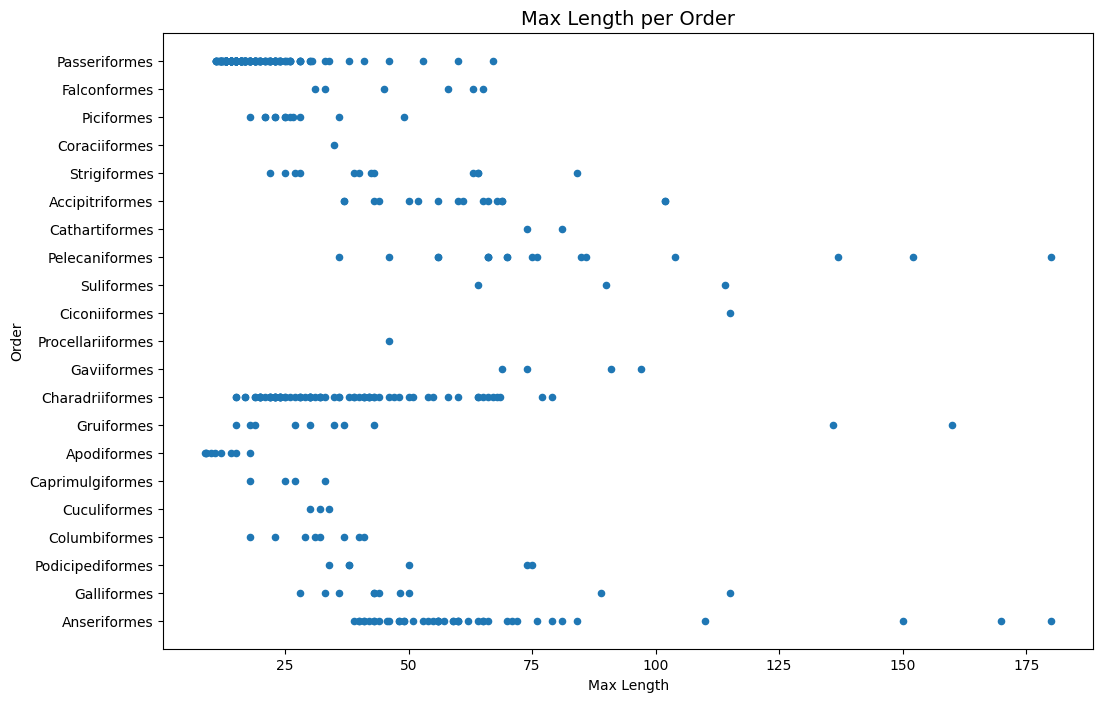

In [2]:
birds.plot(kind="scatter", x="MaxLength", y="Order", figsize=(12, 8))

plt.title("Max Length per Order", fontsize=14)
plt.ylabel("Order")
plt.xlabel("Max Length")

plt.show()

## Working with Histograms

Show the distribution of **MaxBodyMass** for the entire dataset. Divide the array of data into smaller **bins**.

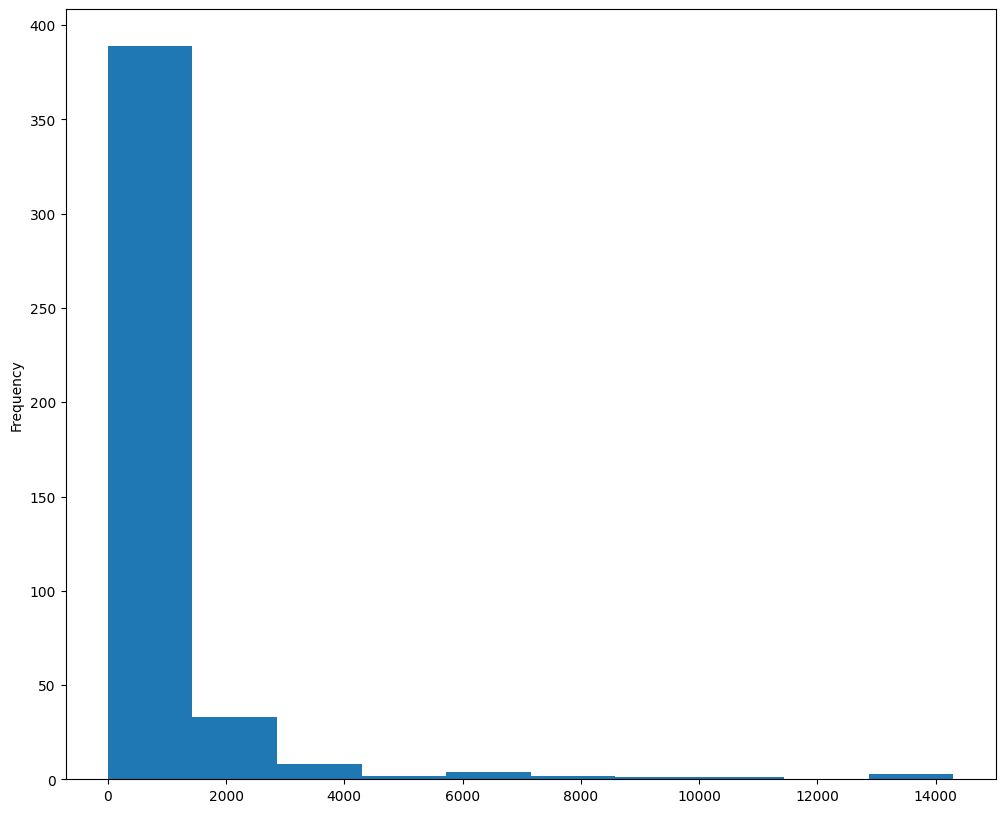

In [3]:
birds["MaxBodyMass"].plot(kind="hist", bins=10, figsize=(12, 10))
plt.show()

Notice that most of the birds, fall in the category of under 2000, for their Max Body Mass. Now try to change the `bins` parameter say to 30:

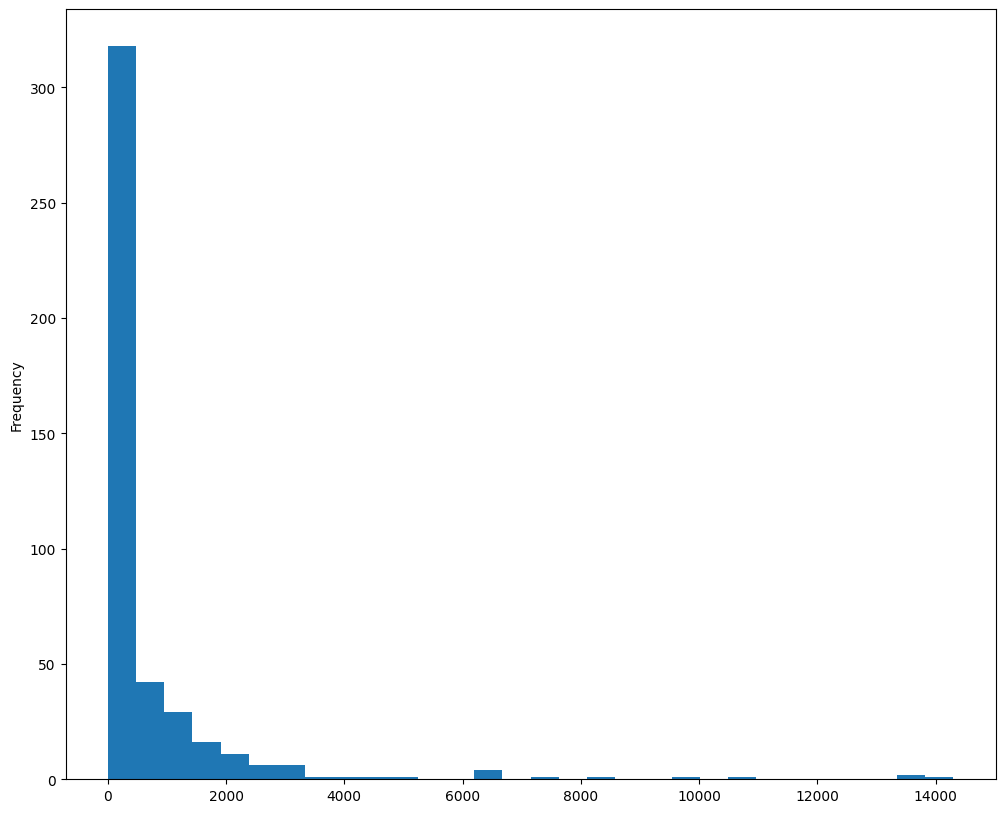

In [4]:
birds["MaxBodyMass"].plot(kind="hist", bins=30, figsize=(12, 10))
plt.show()

##### Filter the data to get only those birds whose body mass is under 60, and show 40 bins:

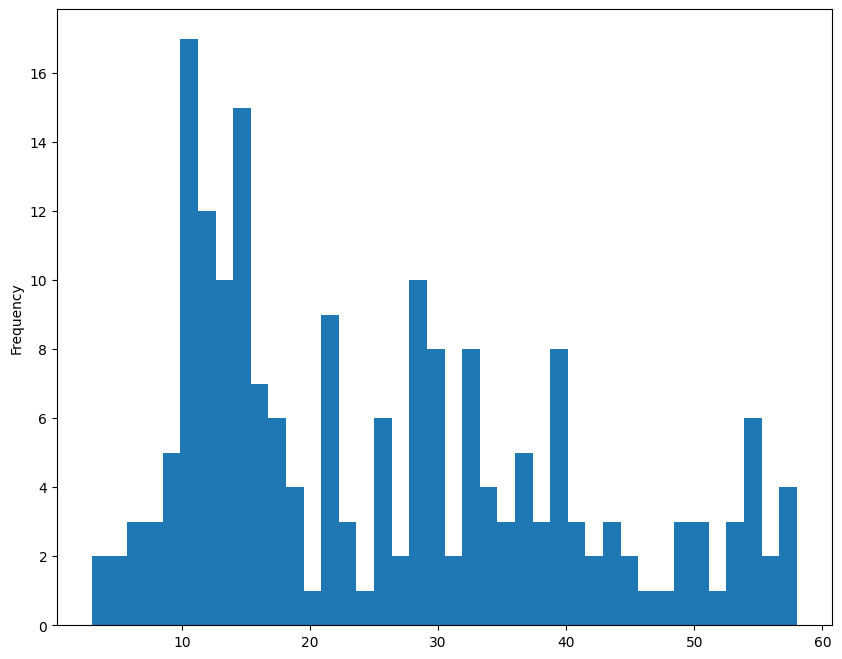

In [5]:
filteredBirds = birds[(birds["MaxBodyMass"] > 1) & (birds["MaxBodyMass"] < 60)]
filteredBirds["MaxBodyMass"].plot(kind="hist", bins=40, figsize=(10, 8))
plt.show()

See a [smoothed version](#below-is-a-smoothed-version-of-a-chart-created-previously) of this jagged histogram.

Create a **2D histogram** to compare the relationship between two distributions: `MaxBodyMass` vs. `MaxLength`. Convergence is shown using brighter colors:

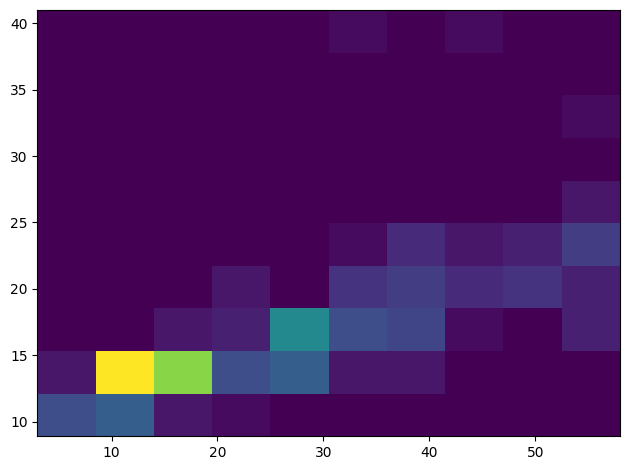

In [6]:
x = filteredBirds["MaxBodyMass"]
y = filteredBirds["MaxLength"]

fig, ax = plt.subplots(tight_layout=True)
hist = ax.hist2d(x, y)

It seems that there is an expected correlation between these two features, with one particular strong point of convergence.

## Explore the dataset for distributions using text data

What is the distribution of the birds according to their conservation status?<br/>


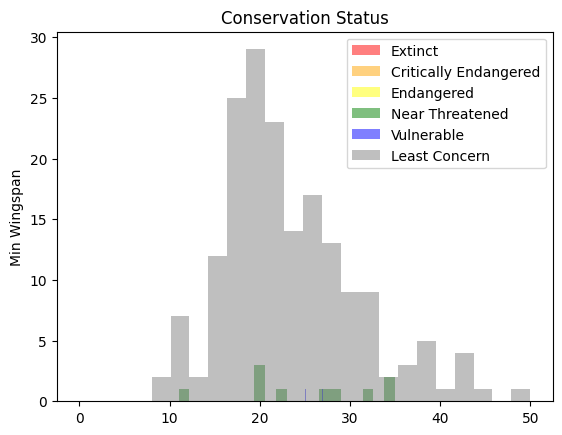

In [7]:
x1 = filteredBirds.loc[filteredBirds.ConservationStatus == "EX", "MinWingspan"]
x2 = filteredBirds.loc[filteredBirds.ConservationStatus == "CR", "MinWingspan"]
x3 = filteredBirds.loc[filteredBirds.ConservationStatus == "EN", "MinWingspan"]
x4 = filteredBirds.loc[filteredBirds.ConservationStatus == "NT", "MinWingspan"]
x5 = filteredBirds.loc[filteredBirds.ConservationStatus == "VU", "MinWingspan"]
x6 = filteredBirds.loc[filteredBirds.ConservationStatus == "LC", "MinWingspan"]

kwargs = dict(alpha=0.5, bins=20)

plt.hist(x1, **kwargs, color="red", label="Extinct")
plt.hist(x2, **kwargs, color="orange", label="Critically Endangered")
plt.hist(x3, **kwargs, color="yellow", label="Endangered")
plt.hist(x4, **kwargs, color="green", label="Near Threatened")
plt.hist(x5, **kwargs, color="blue", label="Vulnerable")
plt.hist(x6, **kwargs, color="gray", label="Least Concern")

plt.gca().set(title="Conservation Status", ylabel="Min Wingspan")
plt.legend()

plt.show()

## Density Plots

To show a smoother density chart, try a **density** plot.

In [8]:
def format_axis():
    plt.grid(axis="both", c="white")
    plt.gca().set_facecolor("#EAEAF2")
    plt.gca().set_axisbelow(True)

    # Hide the lines denoting the data area boundaries.
    for _, spine in plt.gca().spines.items():
        spine.set_visible(False)

    plt.show()

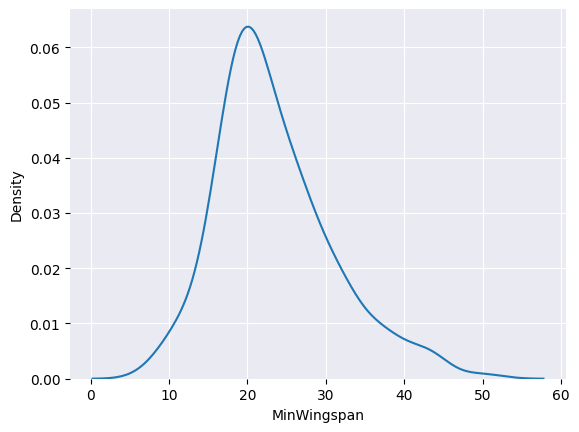

In [9]:
import seaborn as sns

sns.kdeplot(filteredBirds["MinWingspan"])
format_axis()

##### Below is a smoothed version of a [chart created previously](#filter-the-data-to-get-only-those-birds-whose-body-mass-is-under-60-and-show-40-bins)

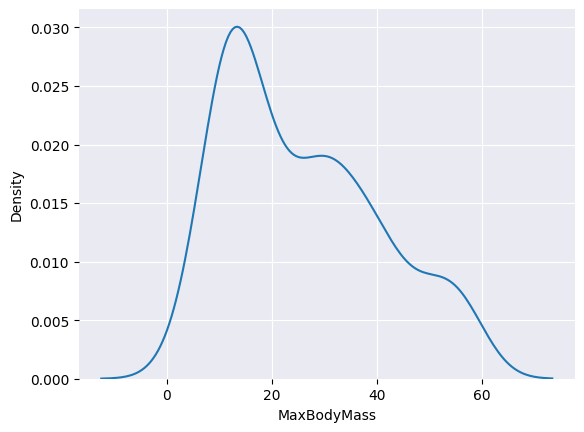

In [10]:
sns.kdeplot(filteredBirds["MaxBodyMass"])
format_axis()

For a smooth but not too smoth line, edit the bandwidth adjust parameter:

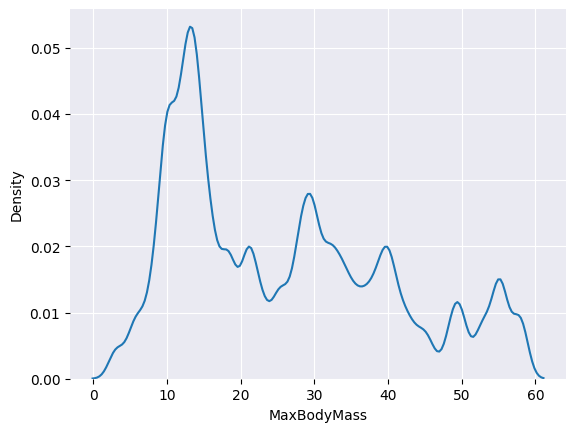

In [11]:
sns.kdeplot(filteredBirds["MaxBodyMass"], bw_adjust=0.2)
format_axis()

Add a `hue mapping` to a second variable (Order). This creates subsets of conditional probability e.g. if the Order = "Columbiformes", this is the density plot: 

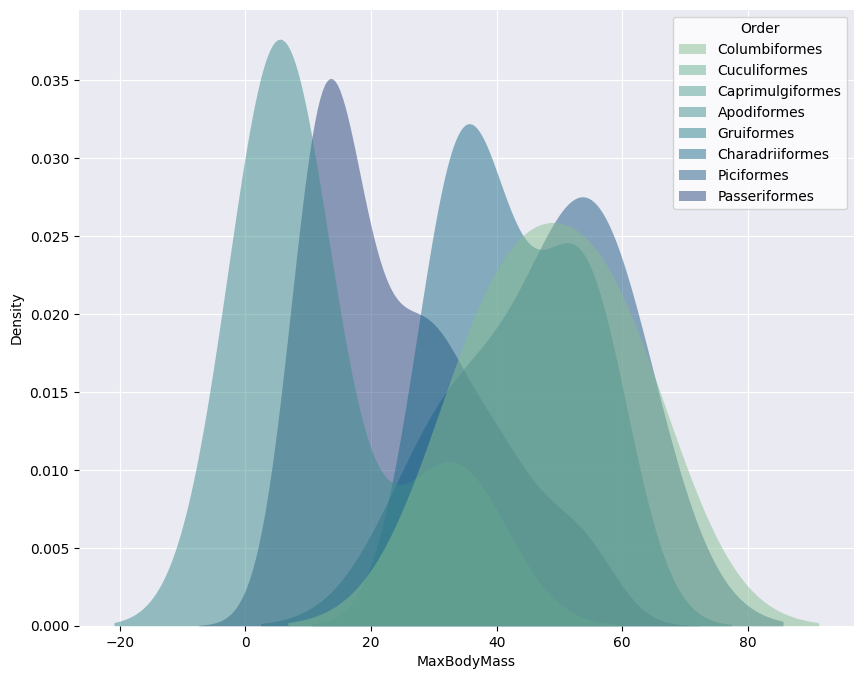

In [18]:
sns.kdeplot(
    data=filteredBirds,
    x="MaxBodyMass",
    hue="Order",
    fill=True,
    common_norm=False,
    palette="crest",
    alpha=0.5,
    linewidth=0,
    warn_singular=False,
)
plt.rcParams["figure.figsize"] = (10, 8)
format_axis()

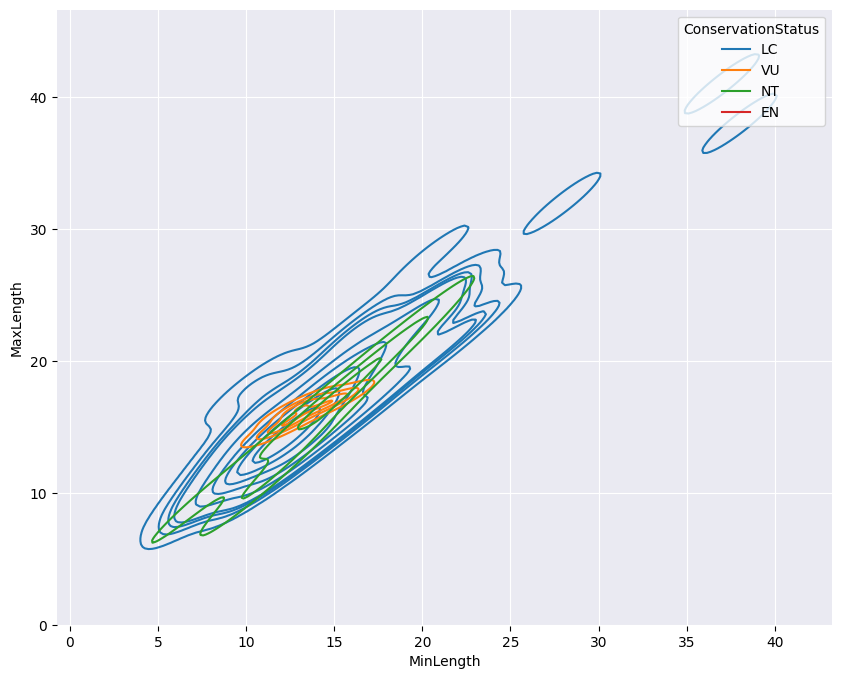

In [20]:
sns.kdeplot(
    data=filteredBirds,
    x="MinLength",
    y="MaxLength",
    hue="ConservationStatus",
    warn_singular=False,
)
format_axis()